# Customer Churn Prediction
## Predicting At-Risk Customers Using Machine Learning
### Author: Brenna Coe | July 2026
### Tools: Python, scikit-learn, Tableau

---

## The Question
Can we predict which telecom customers are likely to churn before they leave —
and which factors matter most in driving that decision?

## The Data
- 7,043 customer records from a telecom company
- 21 variables including tenure, contract type, monthly charges, and services used
- Target variable: Churn (Yes/No) — 26% churn rate
- Source: IBM Telco Customer Churn dataset (Kaggle)

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# ============================================
# STEP 1 — Check data types and missing values
# ============================================

print("Data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nUnique values in TotalCharges:")
print(df['TotalCharges'].unique()[:20])

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling 

In [3]:
# Fix TotalCharges — convert from text to number
# Replace blank spaces with NaN first, then convert
df['TotalCharges'] = df['TotalCharges'].replace(' ', float('nan'))
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Check how many blanks there were
print("Missing TotalCharges after fix:", df['TotalCharges'].isnull().sum())

# Fill those missing values with the median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print("Missing after filling:", df['TotalCharges'].isnull().sum())
print("TotalCharges dtype now:", df['TotalCharges'].dtype)

Missing TotalCharges after fix: 11
Missing after filling: 0
TotalCharges dtype now: float64


/tmp/ipykernel_16/1410731373.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [4]:
# Standardize column names to lowercase with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')
print("Cleaned columns:")
print(df.columns.tolist())

Cleaned columns:
['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']


In [5]:
# Convert Churn from Yes/No text to 1/0 numbers
# This is your target variable — what you're trying to predict
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

print("Churn distribution after conversion:")
print(df['churn'].value_counts())
print("\nChurn rate:", round(df['churn'].mean() * 100, 1), "%")

Churn distribution after conversion:
churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5 %


In [6]:
# Drop customerID — it's just an identifier, not useful for prediction
df = df.drop('customerid', axis=1)
print("Columns remaining:", len(df.columns))
print(df.columns.tolist())

Columns remaining: 20
['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']


In [7]:
# Convert all binary Yes/No columns to 1/0
binary_columns = ['partner', 'dependents', 'phoneservice', 
                  'paperlessbilling', 'multiplelines',
                  'onlinesecurity', 'onlinebackup', 
                  'deviceprotection', 'techsupport',
                  'streamingtv', 'streamingmovies']

for col in binary_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 
                            'No phone service': 0, 
                            'No internet service': 0})

print("Binary columns converted!")
print(df[binary_columns].head())

Binary columns converted!
   partner  dependents  phoneservice  paperlessbilling  multiplelines  \
0        1           0             0                 1              0   
1        0           0             1                 0              0   
2        0           0             1                 1              0   
3        0           0             0                 0              0   
4        0           0             1                 1              0   

   onlinesecurity  onlinebackup  deviceprotection  techsupport  streamingtv  \
0               0             1                 0            0            0   
1               1             0                 1            0            0   
2               1             1                 0            0            0   
3               1             0                 1            1            0   
4               0             0                 0            0            0   

   streamingmovies  
0                0  
1                0

In [8]:
# These columns have more than 2 categories so need different encoding
# pd.get_dummies creates a separate 0/1 column for each category
df = pd.get_dummies(df, columns=['gender', 'internetservice', 
                                   'contract', 'paymentmethod'])

print("Shape after encoding:", df.shape)
print("All columns now numeric:")
print(df.dtypes.value_counts())

Shape after encoding: (7043, 28)
All columns now numeric:
int64      14
bool       12
float64     2
Name: count, dtype: int64


In [9]:
# Confirm everything looks right
print("Final shape:", df.shape)
print("\nAny remaining text columns?")
print(df.select_dtypes(include='object').columns.tolist())
print("\nSample of cleaned data:")
df.head()

Final shape: (7043, 28)

Any remaining text columns?
[]

Sample of cleaned data:


,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,...,internetservice_DSL,internetservice_Fiber optic,internetservice_No,contract_Month-to-month,contract_One year,contract_Two year,paymentmethod_Bank transfer (automatic),paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,0,1,0,1,0,0,0,1,0,0,...,True,False,False,True,False,False,False,False,True,False
1,0,0,0,34,1,0,1,0,1,0,...,True,False,False,False,True,False,False,False,False,True
2,0,0,0,2,1,0,1,1,0,0,...,True,False,False,True,False,False,False,False,False,True
3,0,0,0,45,0,0,1,0,1,1,...,True,False,False,False,True,False,True,False,False,False
4,0,0,0,2,1,0,0,0,0,0,...,False,True,False,True,False,False,False,False,True,False


## Section 3 — Machine Learning Model
Building a logistic regression model to predict customer churn

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Separate features (X) from target (y)
X = df.drop('churn', axis=1)
y = df['churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (7043, 27)
Target shape: (7043,)

Feature columns:
['seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'paperlessbilling', 'monthlycharges', 'totalcharges', 'gender_Female', 'gender_Male', 'internetservice_DSL', 'internetservice_Fiber optic', 'internetservice_No', 'contract_Month-to-month', 'contract_One year', 'contract_Two year', 'paymentmethod_Bank transfer (automatic)', 'paymentmethod_Credit card (automatic)', 'paymentmethod_Electronic check', 'paymentmethod_Mailed check']


In [11]:
# Split data — 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% goes to testing
    random_state=42,    # ensures same split every time you run it
    stratify=y          # keeps churn ratio equal in both splits
)

print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))
print("\nChurn rate in training set:", round(y_train.mean() * 100, 1), "%")
print("Churn rate in testing set:", round(y_test.mean() * 100, 1), "%")

Training set size: 5634
Testing set size: 1409

Churn rate in training set: 26.5 %
Churn rate in testing set: 26.5 %


In [12]:
# Scale numerical features so they're on the same scale
# Important for logistic regression — without this tenure (0-72) 
# would unfairly dominate over binary 0/1 columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully!")
print("Example — tenure before scaling:", X_train['tenure'].mean())
print("Example — tenure after scaling:", X_train_scaled[:, X_train.columns.tolist().index('tenure')].mean().round(4))

Data scaled successfully!
Example — tenure before scaling: 32.48509052183174
Example — tenure after scaling: -0.0


In [13]:
# Build and train the logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print("Number of features used:", model.n_features_in_)

Model trained successfully!
Number of features used: 27


In [14]:
# Use the model to predict on the test set
y_pred = model.predict(X_test_scaled)

# Check overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 1), "%")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churned']))

Model Accuracy: 80.8 %

Detailed Performance Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
     Churned       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



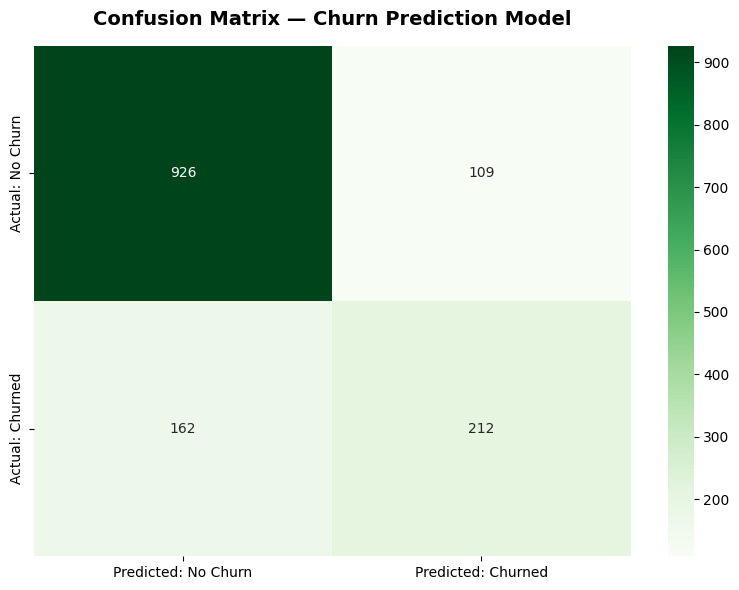


True Negatives  (correctly predicted no churn): 926
False Positives (wrongly flagged as churn):      109
False Negatives (missed actual churners):        162
True Positives  (correctly predicted churn):     212


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Build confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted: No Churn', 'Predicted: Churned'],
            yticklabels=['Actual: No Churn', 'Actual: Churned'])

plt.title('Confusion Matrix — Churn Prediction Model', 
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Plain English breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted no churn): {tn}")
print(f"False Positives (wrongly flagged as churn):      {fp}")
print(f"False Negatives (missed actual churners):        {fn}")
print(f"True Positives  (correctly predicted churn):     {tp}")

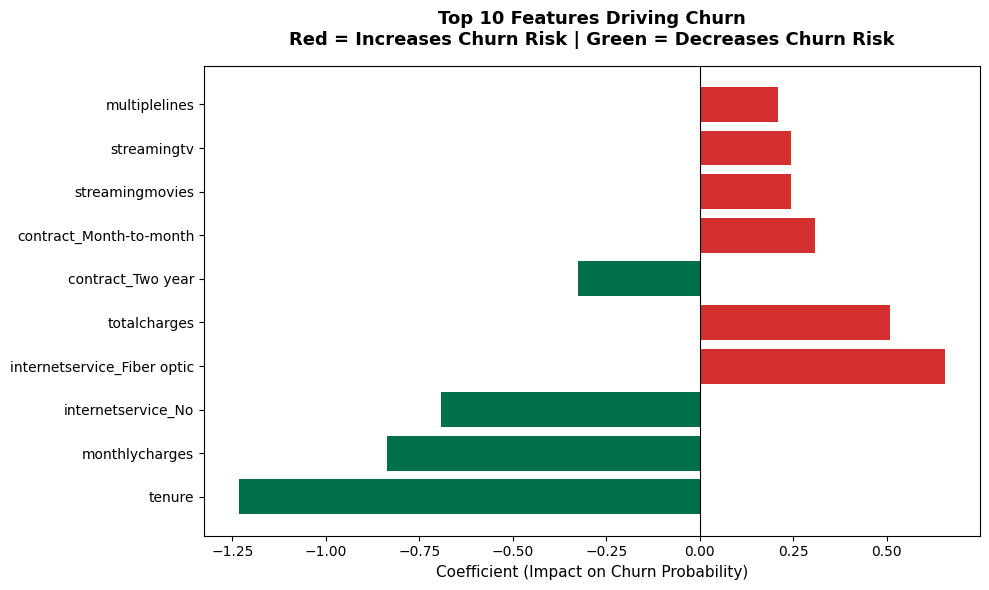


Top 5 churn drivers:
                        feature  coefficient
3                        tenure    -1.231221
13               monthlycharges    -0.837127
19           internetservice_No    -0.692744
18  internetservice_Fiber optic     0.654807
14                 totalcharges     0.507771


In [16]:
# Which factors matter most for predicting churn?
importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})

# Sort by absolute value — biggest impact regardless of direction
importance['abs_coefficient'] = importance['coefficient'].abs()
importance = importance.sort_values('abs_coefficient', ascending=False).head(10)

plt.figure(figsize=(10, 6))
colors = ['#d32f2f' if c > 0 else '#00704A' for c in importance['coefficient']]
bars = plt.barh(importance['feature'], importance['coefficient'], color=colors)

plt.title('Top 10 Features Driving Churn\nRed = Increases Churn Risk | Green = Decreases Churn Risk',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Coefficient (Impact on Churn Probability)', fontsize=11)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nTop 5 churn drivers:")
print(importance[['feature', 'coefficient']].head())

## Section 4 — Visual Analysis
Exploring churn patterns across key customer segments

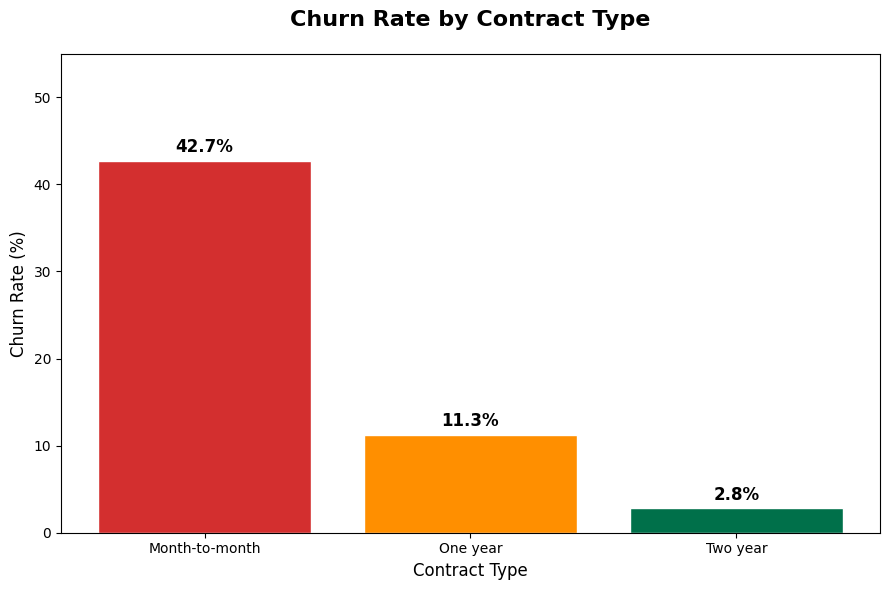

In [17]:
# Chart 1 — Churn Rate by Contract Type
contract_churn = df.groupby(['contract_Month-to-month', 
                              'contract_One year', 
                              'contract_Two year'])['churn'].mean()

# Simpler approach — use original data before encoding
# Reload just for this visualization
df_viz = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_viz['Churn'] = df_viz['Churn'].map({'Yes': 1, 'No': 0})

contract_churn = df_viz.groupby('Contract')['Churn'].mean().reset_index()
contract_churn.columns = ['Contract', 'Churn Rate']
contract_churn['Churn Rate'] = contract_churn['Churn Rate'] * 100
contract_churn = contract_churn.sort_values('Churn Rate', ascending=False)

plt.figure(figsize=(9, 6))
colors = ['#d32f2f', '#ff8f00', '#00704A']
bars = plt.bar(contract_churn['Contract'], 
               contract_churn['Churn Rate'],
               color=colors,
               edgecolor='white')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Churn Rate by Contract Type', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.ylim(0, 55)
plt.tight_layout()
plt.show()

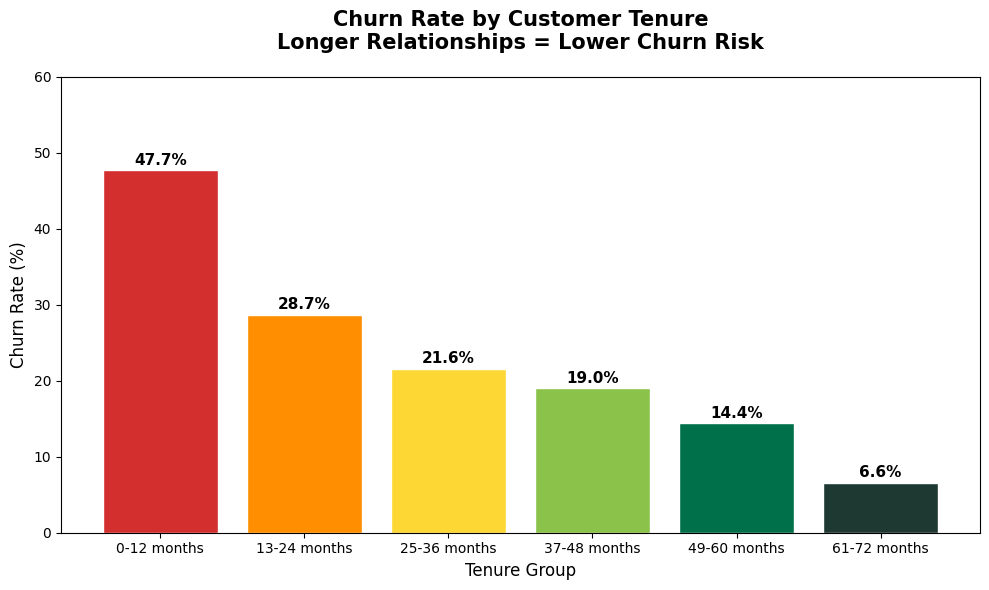

In [18]:
# Chart 2 — Churn Rate by Tenure Group
df_viz['tenure_group'] = pd.cut(df_viz['tenure'], 
                                 bins=[0, 12, 24, 36, 48, 60, 72],
                                 labels=['0-12 months', '13-24 months', '25-36 months',
                                        '37-48 months', '49-60 months', '61-72 months'])

tenure_churn = df_viz.groupby('tenure_group', observed=True)['Churn'].mean().reset_index()
tenure_churn['Churn Rate'] = tenure_churn['Churn'].round(3) * 100

plt.figure(figsize=(10, 6))
colors = ['#d32f2f', '#ff8f00', '#fdd835', '#8bc34a', '#00704A', '#1E3932']
bars = plt.bar(tenure_churn['tenure_group'],
               tenure_churn['Churn Rate'],
               color=colors,
               edgecolor='white')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{height:.1f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Churn Rate by Customer Tenure\nLonger Relationships = Lower Churn Risk',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tenure Group', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.ylim(0, 60)
plt.tight_layout()
plt.show()

## Key Findings

1. **Model achieves 80.8% accuracy** predicting churn on unseen data —
   correctly identifying 212 of 374 at-risk customers in the test set

2. **Tenure is the strongest churn protector** — customers in their
   first year churn at 47.7% vs only 6.6% for customers past 5 years;
   surviving the first 12 months is the critical retention milestone

3. **Contract type creates a 15x churn difference** — month-to-month
   customers churn at 42.7% vs just 2.8% for two-year contracts;
   the single most actionable lever for reducing churn

4. **Fiber optic internet is the top churn risk factor** — despite
   being a premium service, fiber optic customers are most likely
   to leave, suggesting price sensitivity among high-paying customers

5. **Month-to-month + short tenure = highest risk profile** — new
   customers on flexible contracts represent the most urgent
   retention opportunity

## Business Recommendations

1. **Prioritize new customer retention in months 1-12** — offer
   onboarding incentives, check-in calls, or loyalty rewards during
   the critical first year when churn risk is highest at 47.7%

2. **Incentivize contract upgrades** — converting month-to-month
   customers to one-year contracts alone cuts churn risk by 73%;
   a targeted discount or benefit could pay for itself many times over

3. **Investigate fiber optic pricing and satisfaction** — the highest
   churn risk service may indicate a pricing or service quality problem
   worth investigating before investing in further expansion

## Limitations and Next Steps

- Dataset is from one telecom company — findings may vary across
  industries though the contract and tenure dynamics are universal
- Model recall for churners is 57% — meaning 43% of actual churners
  are missed; ensemble methods like Random Forest could improve this
- Next step: test a Random Forest model and compare performance
  to this logistic regression baseline

## Project Links
- [GitHub Repository](https://github.com/bcoe21/customer-churn-prediction)